# Time-series Forecasting on Household Power Consumption
This notebook covers exploratory data analysis for this project.

The general outline follows these steps.
1. Ingest data, reading '?' as NA
2. Interpolate missing data
3. Aggregate to daily mean
4. EDA
5. Stationarity
6. Train/test split

---

## Step 0: Imports and libraries

In [1]:
# ----------------------------------------------
# Step 0: Import libraries set up ennvironment
# ----------------------------------------------

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import pmdarima

## Step 1: Data ingest and pre-processing

In [2]:
df = pd.read_csv('../data/household_power_consumption.csv',
                sep=';', na_values=['?'],
                low_memory=False)
df.index = pd.to_datetime(df['Date'] + ' ' + df['Time'], dayfirst=True)
df.index.name = 'datetime'
df.drop(columns=['Date', 'Time'], inplace=True)

# rename to more descriptive columns
df.columns = ["power", "reactive_power", "voltage", "current", "sub_meter_kitchen", "sub_meter_laundry", "sub_meter_heating"]

# generate a sub_meter_other column
df['sub_meter_other'] = round(df['power'] * 1000 / 60 - (df['sub_meter_kitchen'] + df['sub_meter_laundry'] + df['sub_meter_heating']))

## Step 2: Handle Missing Values

**Decision: Linear interpolation at the minute level**

Missing values appear as `?` (read as `NaN`) and cluster in short gaps rather than extended outages. Three options were considered:

| Approach | Problem |
|---|---|
| Drop rows | Biases daily aggregates downward — a day with 60 missing minutes loses ~4% of observations before averaging |
| Forward-fill | Over-represents the last known state; assumes usage was flat during the gap, which is unlikely for a continuous signal |
| **Linear interpolation** ✓ | Assumes a smooth transition between known values — the most defensible assumption for a continuous physical measurement |

`asfreq('min')` first ensures every minute-level timestamp exists in the index (inserting `NaN` rows for any completely absent timestamps). `interpolate(method='linear')` then fills all `NaN` values by connecting known neighbors with a straight line.

In [3]:
print(f"Missing values before interpolation:\n{df.isnull().sum()}\n")

df = df.asfreq('min')
df = df.interpolate(method='linear')

print(f"Missing values after interpolation:\n{df.isnull().sum()}")

Missing values before interpolation:
power                25979
reactive_power       25979
voltage              25979
current              25979
sub_meter_kitchen    25979
sub_meter_laundry    25979
sub_meter_heating    25979
sub_meter_other      25979
dtype: int64



Missing values after interpolation:
power                0
reactive_power       0
voltage              0
current              0
sub_meter_kitchen    0
sub_meter_laundry    0
sub_meter_heating    0
sub_meter_other      0
dtype: int64


## Step 3: Aggregation

In [4]:
mean_cols = ["power", "reactive_power", "voltage", "current"]
sum_cols  = ["sub_meter_kitchen", "sub_meter_laundry", "sub_meter_heating", "sub_meter_other"]

daily = pd.concat([
    df[mean_cols].resample('D').mean(),
    df[sum_cols].resample('D').sum(),
], axis=1)

daily.head()

,power,reactive_power,voltage,current,sub_meter_kitchen,sub_meter_laundry,sub_meter_heating,sub_meter_other
datetime,,,,,,,,
2006-12-16,3.053475,0.088187,236.243763,13.082828,0.0,546.0,4926.0,14675.0
2006-12-17,2.354486,0.156949,240.087028,9.999028,2033.0,4187.0,13341.0,36941.0
2006-12-18,1.530435,0.112356,241.231694,6.421667,1063.0,2621.0,14018.0,19003.0
2006-12-19,1.157079,0.104821,241.999313,4.926389,839.0,7602.0,6197.0,13124.0
2006-12-20,1.545658,0.111804,242.308062,6.467361,0.0,2648.0,14063.0,20373.0


## Step 4: EDA

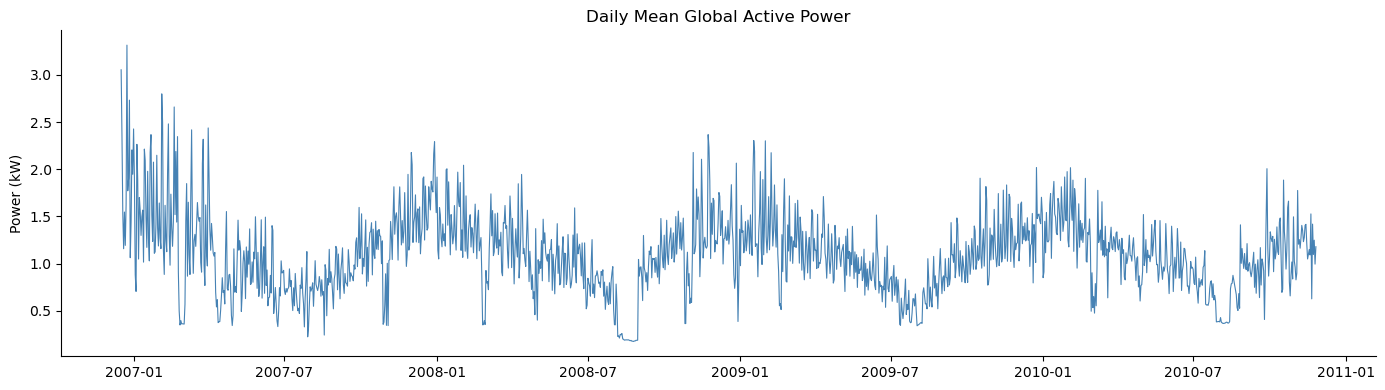

In [5]:
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(daily.index, daily['power'], linewidth=0.8, color='steelblue')
ax.set_title('Daily Mean Global Active Power')
ax.set_ylabel('Power (kW)')
ax.set_xlabel('')
sns.despine()
plt.tight_layout()
plt.show()

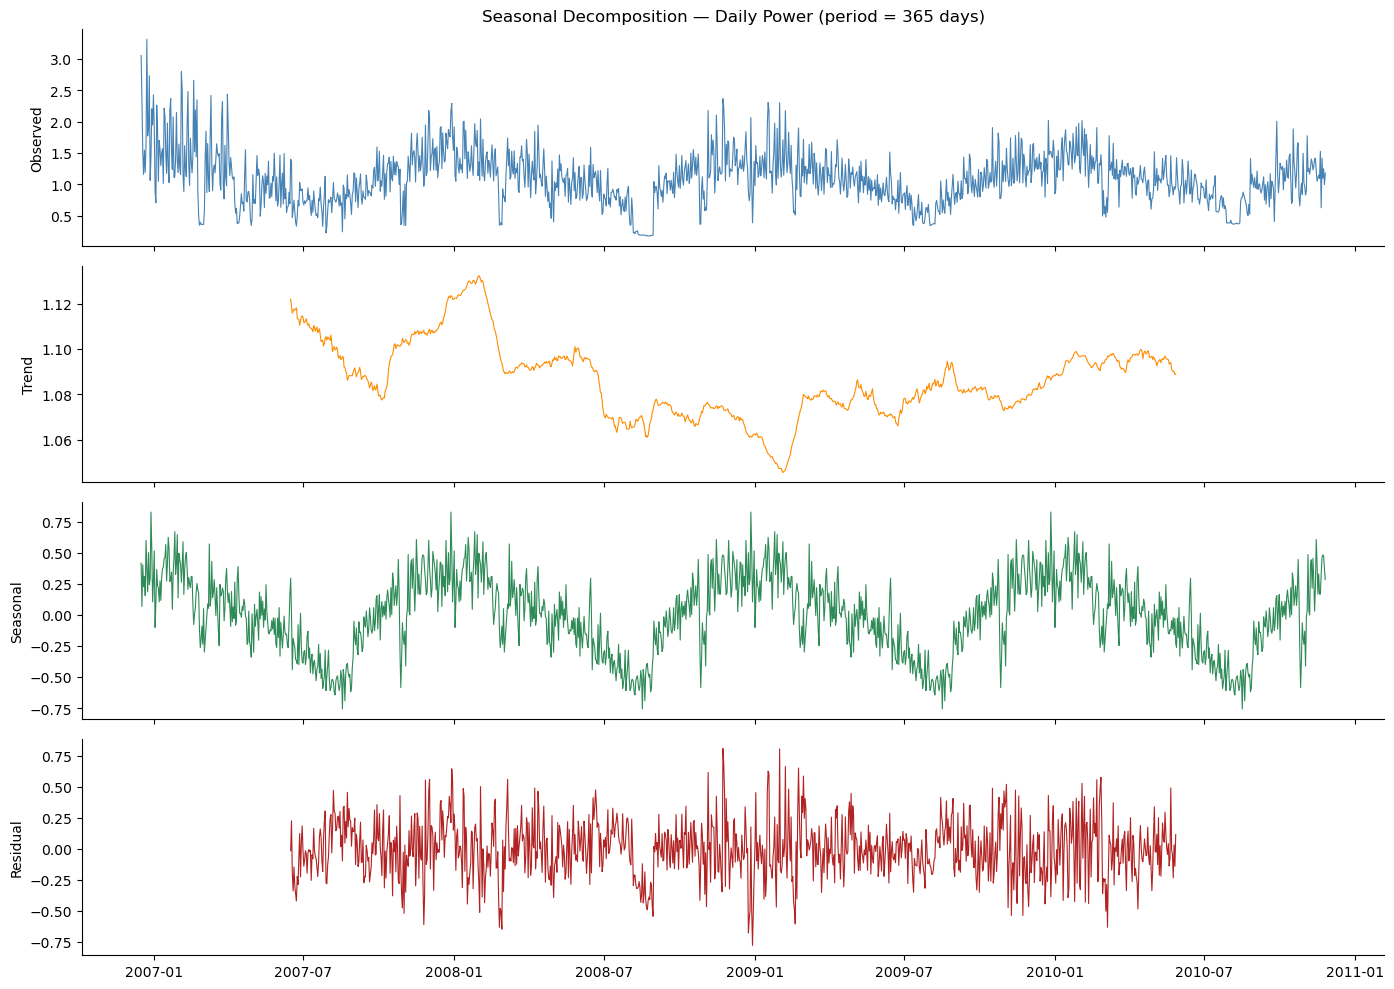

In [6]:
from statsmodels.tsa.seasonal import seasonal_decompose

decomp = seasonal_decompose(daily['power'], model='additive', period=365)

fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)
pairs = [
    ('Observed',  decomp.observed,  'steelblue'),
    ('Trend',     decomp.trend,     'darkorange'),
    ('Seasonal',  decomp.seasonal,  'seagreen'),
    ('Residual',  decomp.resid,     'firebrick'),
]
for ax, (label, series, color) in zip(axes, pairs):
    ax.plot(series, linewidth=0.8, color=color)
    ax.set_ylabel(label)
    sns.despine(ax=ax)

axes[0].set_title('Seasonal Decomposition — Daily Power (period = 365 days)')
plt.tight_layout()
plt.show()

**Trend** is observed by calculating a centered moving average, meaning the moving average requires data both before and after the datapoint. `period=365` says to look 182 days ahead and 182 days behind the datapoint in question.  

Clear **seasonality** is observed with peaks occurring around the beginning of each year, with troughs each year in approximately August. This may suggest that heating makes up a bulk cost in power usage.

**Residuals** after detrending and deseasonalizing show substantial outliers, particularly around the middle of 2008. One way to account for this would be to generate an outlier flag that allows the model to learn explicitly labeled noise without contaminating forecasts.

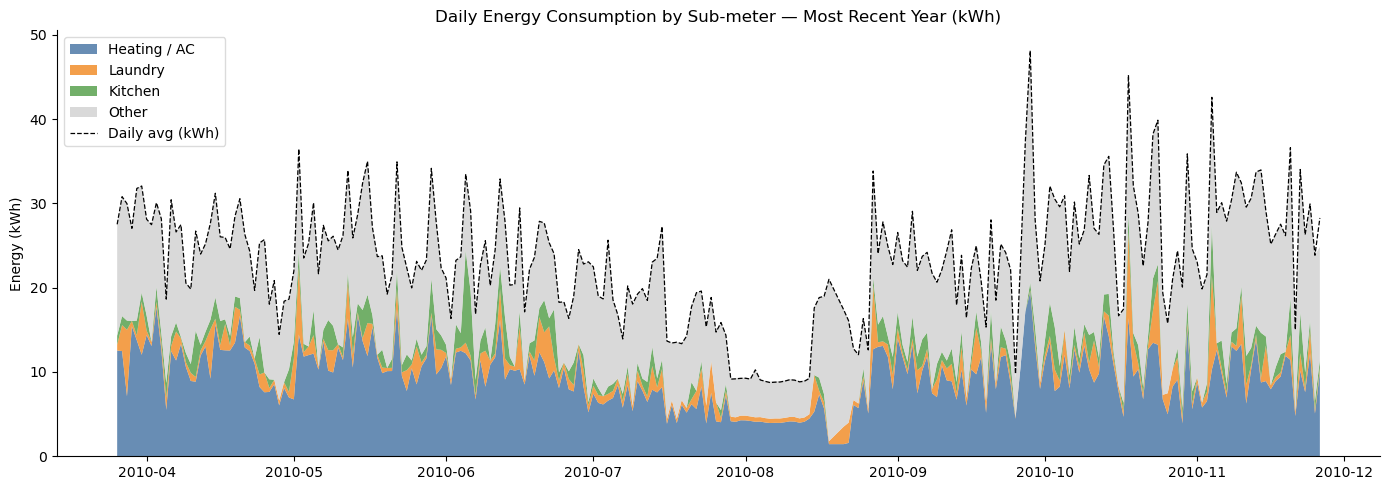

In [7]:
# all sub-meters are in Wh (daily sum) — divide by 1000 to convert to kWh
plot_df = pd.DataFrame(index=daily.index)
plot_df['kitchen'] = daily['sub_meter_kitchen'] / 1000
plot_df['laundry'] = daily['sub_meter_laundry'] / 1000
plot_df['heating'] = daily['sub_meter_heating'] / 1000
plot_df['other']   = daily['sub_meter_other']   / 1000
plot_df['total']   = daily['power'] * 24

# show the most recent year only
cutoff  = plot_df.index.max() - pd.DateOffset(months = 8)
plot_df = plot_df[plot_df.index >= cutoff]

fig, ax = plt.subplots(figsize=(14, 5))
ax.stackplot(
    plot_df.index,
    plot_df['heating'],
    plot_df['laundry'],
    plot_df['kitchen'],
    plot_df['other'],
    labels=['Heating / AC', 'Laundry', 'Kitchen', 'Other'],
    colors=['#4e79a7', '#f28e2b', '#59a14f', '#d3d3d3'],
    alpha=0.85,
)
ax.plot(plot_df.index, plot_df['total'], color='black', linewidth=0.9,
        linestyle='--', label='Daily avg (kWh)')
ax.set_title('Daily Energy Consumption by Sub-meter — Most Recent Year (kWh)')
ax.set_ylabel('Energy (kWh)')
ax.legend(loc='upper left', framealpha=0.7)
sns.despine()
plt.tight_layout()
plt.show()

## Step 5: Stationarity Tests

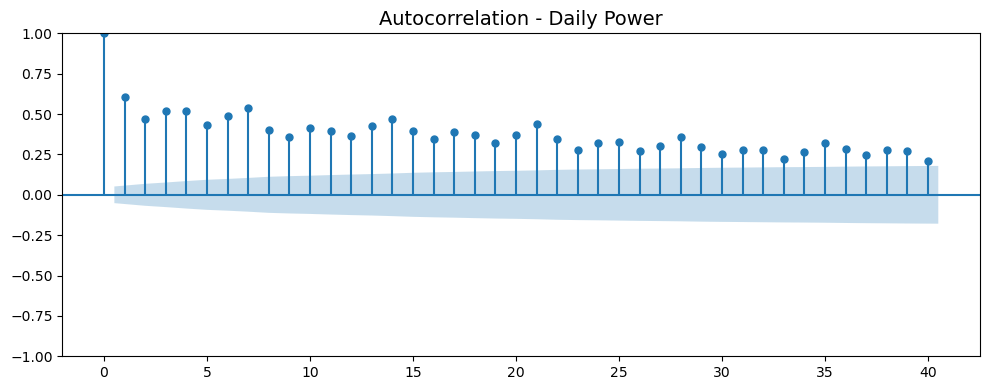

In [8]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# show ACF plot
fig, ax = plt.subplots(figsize=(10, 4))
plot_acf(daily["power"], lags=40, ax=ax)
ax.set_title('Autocorrelation - Daily Power', fontsize=14)
plt.tight_layout()
plt.show()

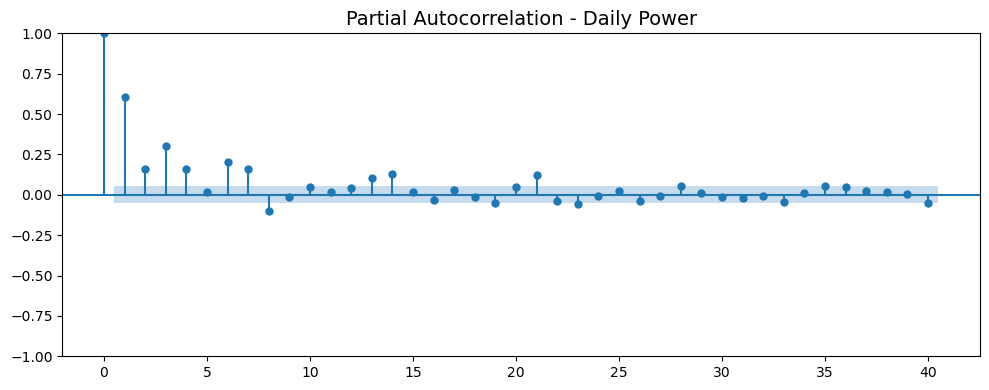

In [9]:
# show PACF plot
fig, ax = plt.subplots(figsize=(10, 4))
plot_pacf(daily["power"], lags=40, ax=ax, method='ywm')
ax.set_title('Partial Autocorrelation - Daily Power', fontsize=14)
plt.tight_layout()
plt.show()


ADF and KPSS are run together because their null hypotheses are **opposites** — agreement between them is more meaningful than either test alone.

| Test | H₀ | H₁ | Reject H₀ when |
|---|---|---|---|
| ADF | Series has a unit root (non-stationary) | Stationary | p < 0.05 |
| KPSS | Series is stationary | Non-stationary | p < 0.05 |

**Interpreting the combination:**

| ADF | KPSS | Conclusion |
|---|---|---|
| Reject (p < 0.05) | Fail to reject (p > 0.05) | Stationary ✓ |
| Fail to reject | Reject | Non-stationary — differencing needed |
| Both reject | Both reject | Trend-stationary — detrend, then difference |
| Both fail to reject | Both fail to reject | Ambiguous |

In [10]:
from statsmodels.tsa.stattools import adfuller, kpss

series = daily['power'].dropna()

# ADF — H0: unit root (non-stationary)
adf_stat, adf_p, _, _, adf_crit, _ = adfuller(series, autolag='AIC')

# KPSS — H0: stationary
kpss_stat, kpss_p, _, kpss_crit = kpss(series, regression='c', nlags='auto')

print("=" * 45)
print(f"{'ADF Test':^45}")
print("=" * 45)
print(f"  Statistic : {adf_stat:.4f}")
print(f"  p-value   : {adf_p:.4f}")
for k, v in adf_crit.items():
    print(f"  Crit ({k}) : {v:.4f}")
print(f"\n  → {'Reject H₀ — stationary' if adf_p < 0.05 else 'Fail to reject H₀ — non-stationary'}")

print()
print("=" * 45)
print(f"{'KPSS Test':^45}")
print("=" * 45)
print(f"  Statistic : {kpss_stat:.4f}")
print(f"  p-value   : {kpss_p:.4f}")
for k, v in kpss_crit.items():
    print(f"  Crit ({k}) : {v:.4f}")
print(f"\n  → {'Reject H₀ — non-stationary' if kpss_p < 0.05 else 'Fail to reject H₀ — stationary'}")

                  ADF Test                   
  Statistic : -3.6867
  p-value   : 0.0043
  Crit (1%) : -3.4350
  Crit (5%) : -2.8636
  Crit (10%) : -2.5679

  → Reject H₀ — stationary

                  KPSS Test                  
  Statistic : 0.1967
  p-value   : 0.1000
  Crit (10%) : 0.3470
  Crit (5%) : 0.4630
  Crit (2.5%) : 0.5740
  Crit (1%) : 0.7390

  → Fail to reject H₀ — stationary


C:\Users\brody\AppData\Local\Temp\ipykernel_32584\1320365340.py:9: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_stat, kpss_p, _, kpss_crit = kpss(series, regression='c', nlags='auto')


ACF plot with slow decay suggests non-stationarity, but both ADF and KPSS agree that the series is stationary. Model may not need first order differencing, but practical testing can confirm this.

## Step 6: Train/test split

Some considerations for a train test split on this dataset
- Must respect temporal order
- Split should avoid the middle of a seasonal change
- Method of cross valdation

In [11]:
train = daily[:'2009-11']
test  = daily['2009-12':]

train_obs, num_features = train.shape
test_obs, _       = test.shape

train_start = train.index.min().strftime('%Y-%m-%d')
train_end   = train.index.max().strftime('%Y-%m-%d')

test_start  = test.index.min().strftime('%Y-%m-%d')
test_end    = test.index.max().strftime('%Y-%m-%d')

print("=" * 45)
print(f"{'Training Set':^45}")
print("=" * 45)

print (f"  Observations : {train_obs}")
print (f"  Features     : {num_features}")
print (f"  Start date   : {train_start}")
print (f"  End date     : {train_end}")

print() 

print("=" * 45)
print(f"{'Test Set':^45}")
print("=" * 45)

print (f"  Observations : {test_obs}")
print (f"  Features     : {num_features}")
print (f"  Start date   : {test_start}")
print (f"  End date     : {test_end}")

                Training Set                 
  Observations : 1081
  Features     : 8
  Start date   : 2006-12-16
  End date     : 2009-11-30

                  Test Set                   
  Observations : 361
  Features     : 8
  Start date   : 2009-12-01
  End date     : 2010-11-26


Every subsequent model will be evaluated on the final 361-day test set for comparison. Walk-forward evaluation uses 12 complete 30-day folds (360 days total), dropping the final observation to avoid a degenerate 1-day fold that would produce unrepresentative per-fold metrics.

In [12]:
# save train/test sets to CSV for modeling step
train.to_csv('../data/daily_train.csv')
test.to_csv('../data/daily_test.csv')